# k_eff Comparison — corrected Green's function

Spatial Green's function and Rossi-alpha across four operating points
$k_\text{eff}\approx 0.98, 0.90, 0.70, 0.40$, using the corrected confined-source sweep
(`project.simulations.greens_sweep`). The earlier version of this notebook reported
$G_\text{facing}/G_\text{away}\approx 1$ at every $k$ and spent several sections hunting for a
"metric artifact" — that flatness was the `FileSource`/`parent_id` attribution bug, not physics.
With correct attribution the directional contrast is **7-50x** and has clear $k$-dependence.

**Physical picture.** Far below critical the chain is short, so $G$ is dominated by *direct
geometric coupling* — cells facing the detector win, strong distance dependence. Near critical
the chain is long and relaxes to the fundamental mode, so $G$ is dominated by *importance*
(centre-peaked, direction-independent); the directional contrast collapses.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

from project.analysis import greens_loader as gl

FIGURES_DIR = Path("../outputs/keff_comparison")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

LABELS = ["098", "090", "070", "040"]
COLORS = {"098": "C3", "090": "C1", "070": "C2", "040": "C0"}
sweeps = {L: gl.load_sweep(L) for L in LABELS}
F = {L: gl.fission_coarse(L, *sweeps[L]["G"].shape) for L in LABELS}
for L in LABELS:
    s = sweeps[L]
    print(f"k={s['k']:.2f}: R={s['R']:.2f} cm, grid {s['G'].shape}, "
          f"G range {s['G'].min():.2e}..{s['G'].max():.2e}, "
          f"near/far={s['G'][-1,0]/s['G'][-1,-1]:.1f}x")

k=0.98: R=28.70 cm, grid (20, 20), G range 4.69e-03..6.37e-02, near/far=6.6x
k=0.90: R=24.50 cm, grid (20, 20), G range 1.01e-03..3.51e-02, near/far=25.0x
k=0.70: R=17.70 cm, grid (20, 20), G range 6.10e-04..3.46e-02, near/far=48.7x
k=0.40: R=11.40 cm, grid (20, 20), G range 8.80e-04..3.28e-02, near/far=34.5x


## 1. $G_i(r,\theta)$ heatmaps (shared log scale)

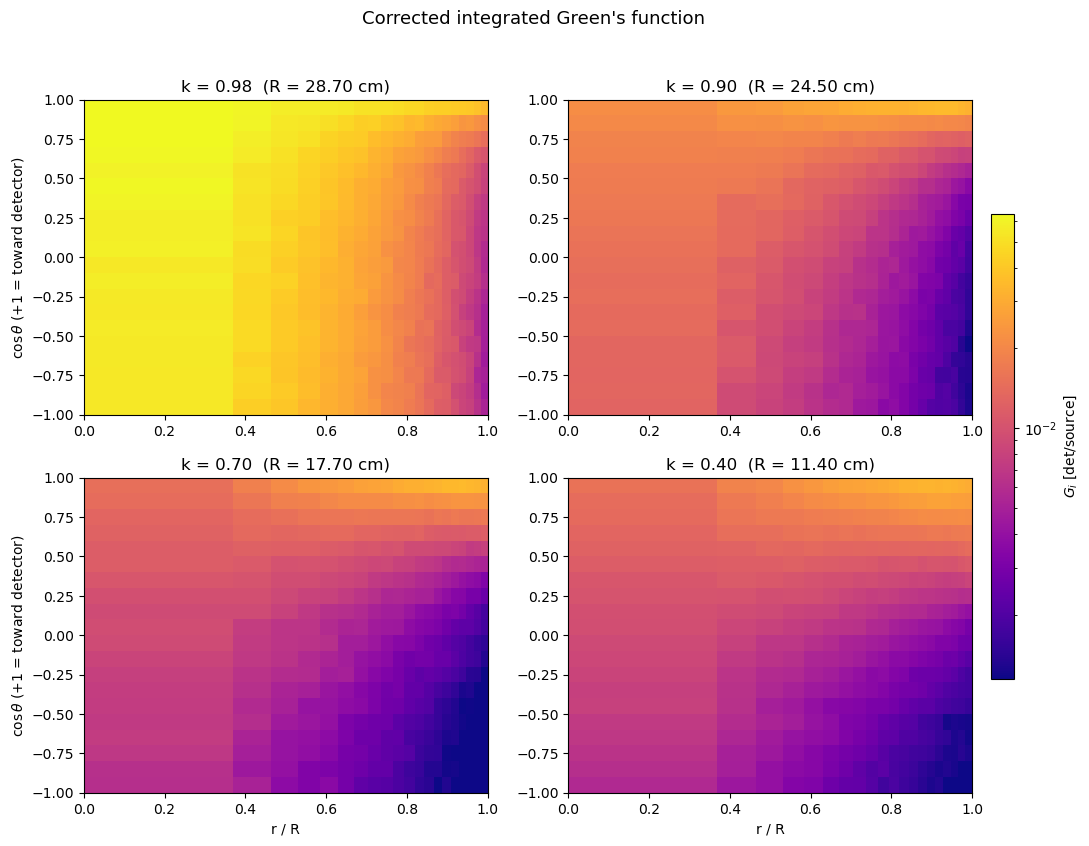

In [2]:
G_all = np.concatenate([sweeps[L]["G"].ravel() for L in LABELS])
norm = LogNorm(vmin=np.percentile(G_all[G_all > 0], 2), vmax=G_all.max())

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for idx, (ax, L) in enumerate(zip(axes.flat, LABELS)):
    s = sweeps[L]
    r_unit = s["r_edges"] / s["R"]
    im = ax.pcolormesh(r_unit, s["cos_edges"], s["G"].T, cmap="plasma",
                       shading="flat", norm=norm)
    if idx >= 2:                       # bottom row only
        ax.set_xlabel("r / R")
    if idx % 2 == 0:                   # left column only
        ax.set_ylabel(r"$\cos\theta$ (+1 = toward detector)")
    ax.set_title(f"k = {s['k']:.2f}  (R = {s['R']:.2f} cm)")
fig.colorbar(im, ax=axes.ravel().tolist(), label=r"$G_i$ [det/source]",
             fraction=0.025, pad=0.02)
fig.suptitle("Corrected integrated Green's function", fontsize=13)
plt.savefig(FIGURES_DIR / "Gi_heatmaps.png", dpi=200, bbox_inches="tight")
plt.show()

### Same heatmaps as polar meridional slices

The identical $G_i$ data as physical core cross-sections (disk centre = core centre, rim =
surface, **detector at the top**). The shift from a centre-bright disk (importance, k=0.98) to a
top-bright / bottom-dark disk (direct detector coupling, k=0.40) is immediately visible.

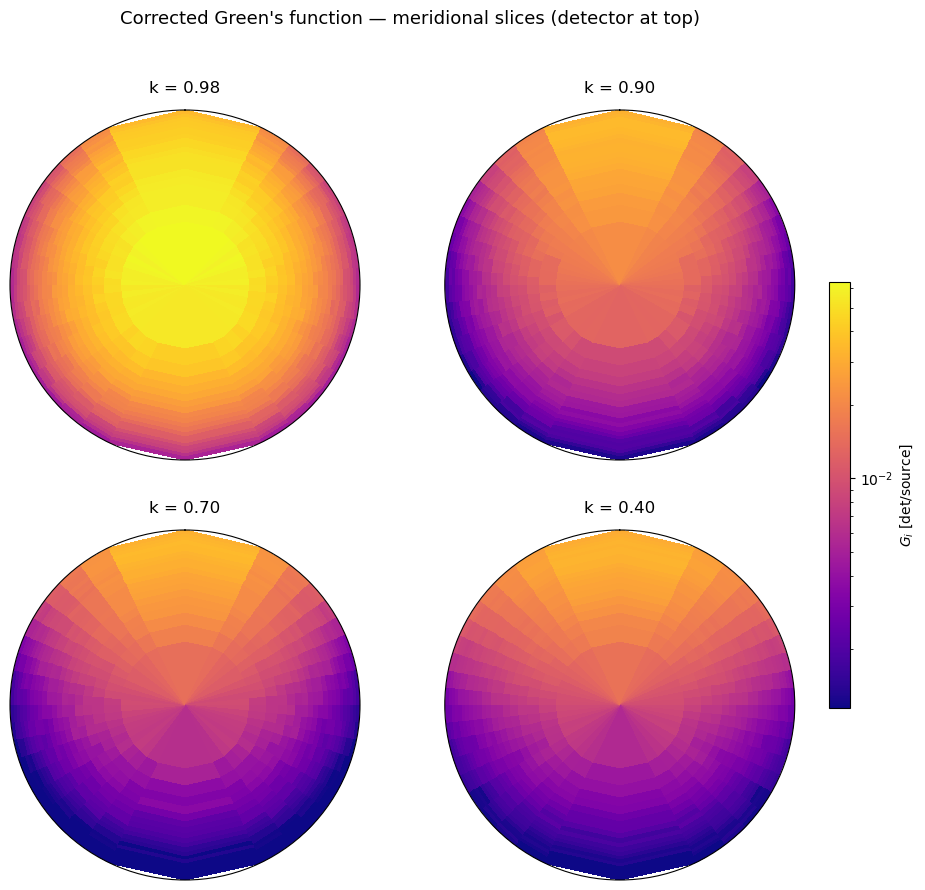

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10), subplot_kw={"projection": "polar"})
for ax, L in zip(axes.flat, LABELS):
    im = gl.polar_meridian(ax, sweeps[L], norm=norm)
    ax.set_title(f"k = {sweeps[L]['k']:.2f}", pad=12)
fig.colorbar(im, ax=axes.ravel().tolist(), label=r"$G_i$ [det/source]", fraction=0.025, pad=0.04)
fig.suptitle("Corrected Green's function — meridional slices (detector at top)", fontsize=13)
plt.savefig(FIGURES_DIR / "Gi_polar.png", dpi=200, bbox_inches="tight")
plt.show()

## 2. Distance dependence and the near/far trend

Left: $G$ vs distance for every $k$. Right: the near-pole/far-pole ratio vs $k$ — the headline
result, versus the buggy method's flat $\approx 1$.

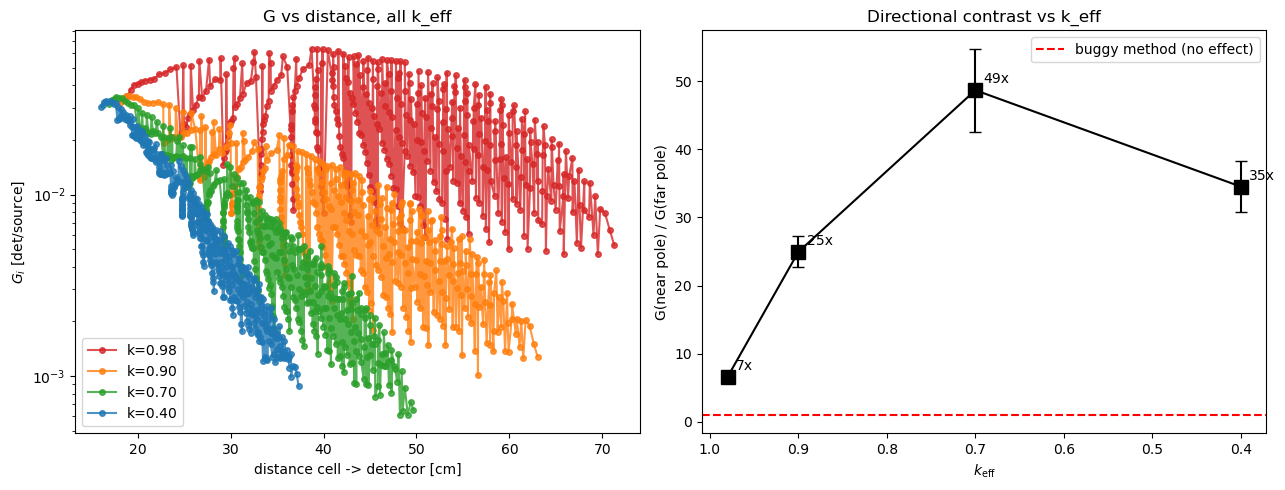

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
for L in LABELS:
    s = sweeps[L]
    d = s["dist"].ravel(); G = s["G"].ravel(); o = np.argsort(d)
    ax1.plot(d[o], G[o], "o-", ms=4, alpha=0.8, color=COLORS[L], label=f"k={s['k']:.2f}")
ax1.set_yscale("log"); ax1.set_xlabel("distance cell -> detector [cm]")
ax1.set_ylabel(r"$G_i$ [det/source]"); ax1.set_title("G vs distance, all k_eff")
ax1.legend()

ks = [sweeps[L]["k"] for L in LABELS]
ratio = [sweeps[L]["G"][-1, 0] / sweeps[L]["G"][-1, -1] for L in LABELS]
rerr = [r * np.sqrt(1/max(sweeps[L]["n_prompt"][-1,0],1) + 1/max(sweeps[L]["n_prompt"][-1,-1],1))
        for L, r in zip(LABELS, ratio)]
ax2.errorbar(ks, ratio, yerr=rerr, fmt="s-", ms=10, capsize=4, color="black")
ax2.axhline(1.0, ls="--", color="red", label="buggy method (no effect)")
for k, r in zip(ks, ratio):
    ax2.annotate(f"{r:.0f}x", (k, r), textcoords="offset points", xytext=(6, 5))
ax2.set_xlabel(r"$k_\text{eff}$"); ax2.set_ylabel("G(near pole) / G(far pole)")
ax2.set_title("Directional contrast vs k_eff"); ax2.legend(); ax2.invert_xaxis()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "distance_and_ratio.png", dpi=200, bbox_inches="tight")
plt.show()

## 3. Radial (importance) vs angular (direction) profiles across k_eff

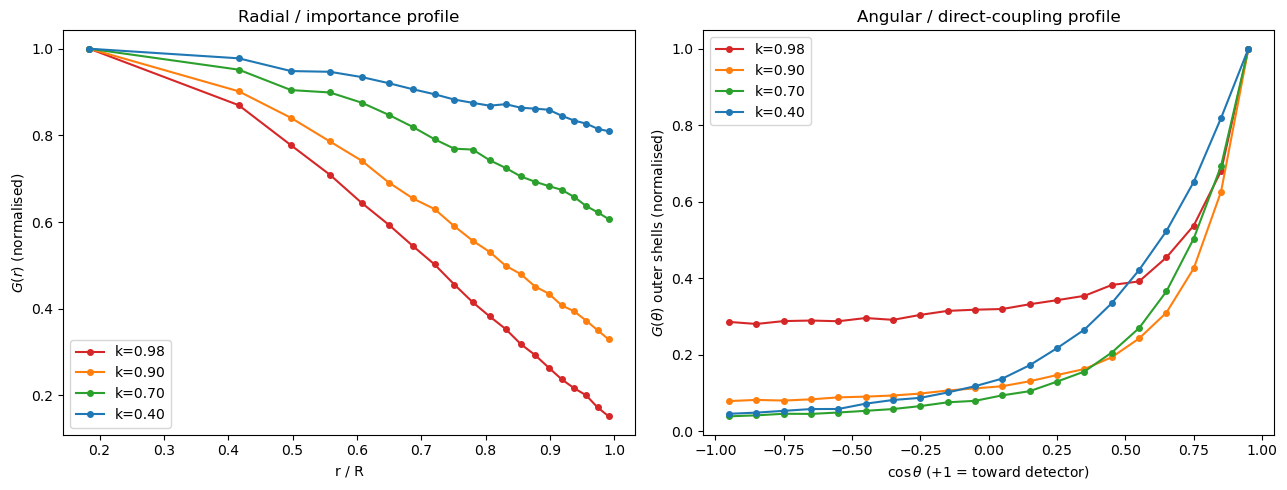

In [5]:
fig, (axr, axt) = plt.subplots(1, 2, figsize=(13, 5))
for L in LABELS:
    s = sweeps[L]
    r1d, G_r, G_r_err = gl.radial_profile(s)
    axr.plot(r1d / s["R"], G_r / G_r.max(), "o-", ms=4, color=COLORS[L], label=f"k={s['k']:.2f}")
    cos1d, G_th, _ = gl.angular_profile(s, r_frac_min=0.75)
    axt.plot(cos1d, G_th / G_th.max(), "o-", ms=4, color=COLORS[L], label=f"k={s['k']:.2f}")
axr.set_xlabel("r / R"); axr.set_ylabel(r"$G(r)$ (normalised)")
axr.set_title("Radial / importance profile"); axr.legend()
axt.set_xlabel(r"$\cos\theta$ (+1 = toward detector)")
axt.set_ylabel(r"$G(\theta)$ outer shells (normalised)")
axt.set_title("Angular / direct-coupling profile"); axt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "profiles_vs_k.png", dpi=200, bbox_inches="tight")
plt.show()

## 3b. Direct vs multiplied: directional contrast vs arrival time

Why is the *integrated* near/far contrast "only" ~7× at k=0.98 when the directional physics looks so
strong? Because the time-integrated $G_i$ mixes two channels with opposite behaviour. Splitting the
outer-shell detections by **arrival time** separates them:

* **Early (direct first-flight)** — the source neutron itself streams to the detector. Strongly
  directional at every $k$ (facing/away reaches ~10²).
* **Late (fission chain)** — descendants leak after the chain has relaxed toward the fundamental
  mode, which is direction-independent, so the contrast collapses toward 1.

Near critical the long-lived chain channel dominates the time integral, washing the *integrated*
contrast down to ~7×; far below critical the direct channel weighs more, so integrated contrast
grows. (Time resolution is 19.5 µs/bin from the linear `g_t`; the trend is sharpest at k=0.98.)

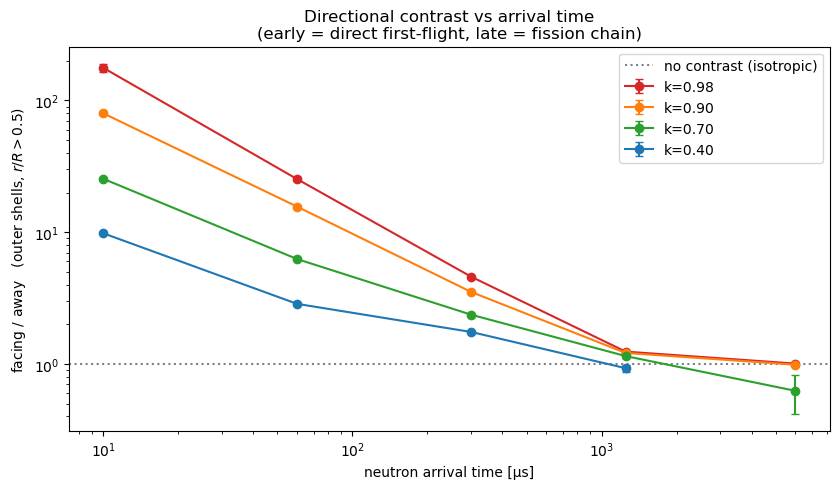

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 5))
for L in LABELS:
    d = gl.directional_vs_time(sweeps[L])          # cols: t_centre, ratio, err, n_f, n_a
    ax.errorbar(d[:, 0] * 1e6, d[:, 1], yerr=d[:, 2], marker="o", capsize=3,
                color=COLORS[L], label=f"k={sweeps[L]['k']:.2f}")
ax.axhline(1.0, ls=":", color="gray", label="no contrast (isotropic)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("neutron arrival time [µs]")
ax.set_ylabel("facing / away   (outer shells, $r/R>0.5$)")
ax.set_title("Directional contrast vs arrival time\n(early = direct first-flight, late = fission chain)")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "directional_vs_time.png", dpi=200, bbox_inches="tight")
plt.show()

## 4. Radial fission-rate profiles $F(r)$

From the fission mesh tally (scored during transport — unaffected by the attribution bug). Lower
$k_\text{eff}$ → smaller core → more surface-peaked.

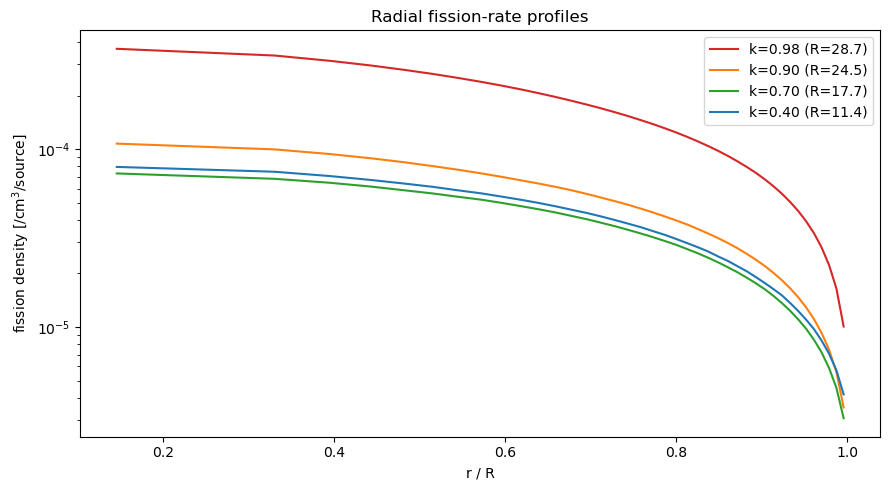

In [7]:
from project.core.rossi_mesh import N_RADIAL, N_THETA
import openmc
fig, ax = plt.subplots(figsize=(9, 5))
for L in LABELS:
    s = sweeps[L]; R = s["R"]
    res_dir = gl.RESULTS_ROOT / gl._FISSION_DIR[L]
    with openmc.StatePoint(str(res_dir / "statepoint.1.h5")) as sp:
        Ft = sp.get_tally(name="fission_per_cell").mean.flatten().reshape(N_THETA, N_RADIAL)
    F_radial = Ft.sum(axis=0)
    V_shell = (4/3)*np.pi*R**3 / N_RADIAL
    r_edges_phys = R * np.linspace(0, 1, N_RADIAL + 1) ** (1/3)
    r_mid_unit = 0.5*(r_edges_phys[:-1] + r_edges_phys[1:]) / R
    ax.plot(r_mid_unit, F_radial / V_shell, color=COLORS[L], label=f"k={s['k']:.2f} (R={R:.1f})")
ax.set_yscale("log"); ax.set_xlabel("r / R")
ax.set_ylabel(r"fission density [/cm$^3$/source]")
ax.set_title("Radial fission-rate profiles"); ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fission_profiles.png", dpi=200, bbox_inches="tight")
plt.show()

## 5. Rossi-alpha and point kinetics — what the comparison means

We fit the corrected $R(\tau)=\sum_i F_i\int g_i(t)g_i(t+\tau)\,dt$ to $A+Be^{\alpha\tau}$ and read off
the prompt decay constant $\alpha$. Prompt point kinetics (a **zero-dimensional** model) predicts
$$\alpha=\frac{k_p-1}{\ell},\qquad k_p=(1-\beta)\,k_\text{eff},$$
where $\ell$ is the **prompt neutron lifetime** (a material property; $\beta\approx0.0065$ for U235;
the generation time is $\Lambda_\text{gen}=\ell/k$). So $\ell=(k_p-1)/\alpha$ should come out the same
from each independent $k_\text{eff}$ run. What this comparison buys us:

1. **Time-dynamics validation.** A single $\ell\approx 52~\mu$s reproduced across all four $k_\text{eff}$
   ($\pm$~17%) is a falsifiable check — not just "$\alpha$ grows when subcritical", but the exact
   textbook relation — anchoring our absolute time scale to a material constant.
2. **A clean separation of what each method captures.** $R(\tau)\approx(\text{spatial amplitude }
   \sum_i F_i\!\int g_i g_i)\times e^{\alpha\tau}$. Point kinetics is the scalar $e^{\alpha\tau}$ — the
   fundamental-mode *time* decay. The spatially-resolved Green's function is exactly the *amplitude /
   shape* that a 0-D model discards: the importance and distance-to-detector structure. **The spatial
   $G_i$ is the part beyond point kinetics** — i.e. the whole point of the method.
3. **It explains the near-critical wash-out.** The same fundamental-mode dominance that makes point
   kinetics accurate is what makes the integrated $G_i$ importance-shaped (centre-peaked,
   direction-independent) near critical. As $k$ drops, $\alpha$ still follows point kinetics (slowest
   mode), but $G_i$ develops the directional/distance structure point kinetics cannot represent.
4. **What it means *now*, after the bug fix.** $\alpha$ lives entirely in detection *times*, which were
   always correct; the attribution bug scrambled spatial *labels*, never times. So the good $\alpha$-fit
   was **orthogonal** to the spatial bug — never evidence for or against it. The old "flat $G$" was a
   random-label artifact, distinguishable from genuine near-critical importance flatness by its strong
   radial structure and $k$-dependence (Sections 1–3b). Bottom line: **point kinetics is the 0-D sanity
   anchor (validates the dynamics, sets $\ell$); the corrected spatial $G_i$ is the actual result.**

k=0.98: alpha = -616.1 +/- 13.9 s^-1  (tau = 1.623 ms)
k=0.90: alpha = -2274.1 +/- 29.7 s^-1  (tau = 0.440 ms)
k=0.70: alpha = -5561.6 +/- 22.9 s^-1  (tau = 0.180 ms)
k=0.40: alpha = -9686.0 +/- 56.7 s^-1  (tau = 0.103 ms)

prompt lifetime l across k: mean=51.58 us, std/mean=16.8%


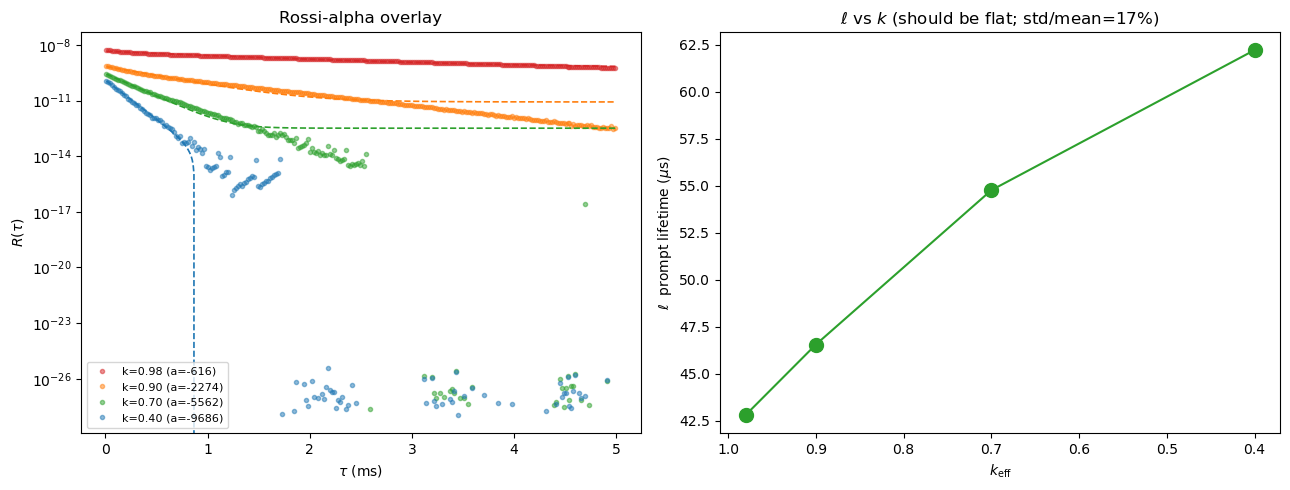

In [8]:
BETA = 0.0065
rossi = {}
for L in LABELS:
    tau, R_tau = gl.rossi(sweeps[L], F[L])
    popt, perr = gl.fit_alpha(tau, R_tau)
    rossi[L] = {"tau": tau, "R": R_tau, "alpha": popt[2], "aerr": perr[2]}
    print(f"k={sweeps[L]['k']:.2f}: alpha = {popt[2]:.1f} +/- {perr[2]:.1f} s^-1  "
          f"(tau = {-1/popt[2]*1e3:.3f} ms)")

ks = np.array([sweeps[L]["k"] for L in LABELS])
alphas = np.array([rossi[L]["alpha"] for L in LABELS])
ell = ((1 - BETA) * ks - 1) / alphas * 1e6   # prompt neutron lifetime, us
print(f"\nprompt lifetime l across k: mean={ell.mean():.2f} us, std/mean={ell.std(ddof=1)/ell.mean():.1%}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
for L in LABELS:
    r = rossi[L]
    ax1.plot(r["tau"]*1e3, r["R"], "o", ms=3, alpha=0.5, color=COLORS[L],
             label=f"k={sweeps[L]['k']:.2f} (a={r['alpha']:.0f})")
    tf = np.linspace(r["tau"][0], r["tau"][-1], 600)
    ax1.plot(tf*1e3, gl.rossi_model(tf, *gl.fit_alpha(r["tau"], r["R"])[0]), "--",
             lw=1.2, color=COLORS[L])
ax1.set_yscale("log"); ax1.set_xlabel(r"$\tau$ (ms)"); ax1.set_ylabel(r"$R(\tau)$")
ax1.set_title("Rossi-alpha overlay"); ax1.legend(fontsize=8)

ax2.plot(ks, ell, "o-", ms=10, color="C2")
ax2.set_xlabel(r"$k_\text{eff}$"); ax2.set_ylabel(r"$\ell$  prompt lifetime ($\mu$s)")
ax2.set_title(fr"$\ell$ vs $k$ (should be flat; std/mean={ell.std(ddof=1)/ell.mean():.0%})")
ax2.invert_xaxis()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "rossi_and_lambda.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Summary table

In [9]:
print("| k_eff | R (cm) | G near pole | G far pole | near/far | alpha (s^-1) | tau (ms) |")
print("|-------|--------|-------------|------------|----------|--------------|----------|")
for L in LABELS:
    s = sweeps[L]; a = rossi[L]["alpha"]
    print(f"| {s['k']:.2f}  | {s['R']:.2f}  | {s['G'][-1,0]:.3e} | {s['G'][-1,-1]:.3e} | "
          f"{s['G'][-1,0]/s['G'][-1,-1]:5.1f}x  | {a:+.0f}      | {-1/a*1e3:.3f}   |")
r_sub = max(sweeps[L]["G"][-1,0]/sweeps[L]["G"][-1,-1] for L in ["070","090","040"])
r_crit = sweeps["098"]["G"][-1,0]/sweeps["098"]["G"][-1,-1]
print(f"\nDirectional contrast collapses from ~{r_sub:.0f}x (subcritical) to {r_crit:.0f}x near "
      f"critical: importance (centre-peaked) overtakes direct geometric coupling as k_eff -> 1.")
print("(The confined-source proof in greens_per_cell.py resolves the outermost cells more finely, "
      "giving up to ~50x.)")

| k_eff | R (cm) | G near pole | G far pole | near/far | alpha (s^-1) | tau (ms) |
|-------|--------|-------------|------------|----------|--------------|----------|
| 0.98  | 28.70  | 3.473e-02 | 5.260e-03 |   6.6x  | -616      | 1.623   |
| 0.90  | 24.50  | 3.194e-02 | 1.280e-03 |  25.0x  | -2274      | 0.440   |
| 0.70  | 17.70  | 3.164e-02 | 6.500e-04 |  48.7x  | -5562      | 0.180   |
| 0.40  | 11.40  | 3.038e-02 | 8.800e-04 |  34.5x  | -9686      | 0.103   |

Directional contrast collapses from ~49x (subcritical) to 7x near critical: importance (centre-peaked) overtakes direct geometric coupling as k_eff -> 1.
(The confined-source proof in greens_per_cell.py resolves the outermost cells more finely, giving up to ~50x.)
